# Train/Test Splitting

To test our models, we need to see how they do on unseen instances. To achieve this, we divide our data into a training set and a testing set. We only train our data on the training set, that way we can assess how well it does on the testing set.

How should we split the dataset?

## Method One: Holdout method
- "hold out" some instances for testing
    - Train on the remaining instances
- Typically use a standard "split" or percentage holdout
    - 2:1 split: holdout 1/3 for testing, train on remaining 2/3
    - 25% holdout: holdout 25% for testing, train on remaining 75%
        - Sci-kit learn default for train_test_split()


In [58]:
import pandas as pd
df = pd.read_csv("shirt_sizes_long.csv")
X = df.drop(["t-shirt size"], axis="columns")
y = df["t-shirt size"]
print(X)
print(y)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X) # fitting it will determine the minimum and maximum values for each feature

X_scaled = scaler.transform(X)

    height(cm)  weight(kg)
0          158          58
1          158          59
2          158          63
3          160          59
4          160          60
5          163          60
6          163          61
7          160          64
8          163          64
9          165          61
10         165          62
11         165          65
12         168          62
13         168          63
14         168          66
15         170          63
16         170          64
17         170          68
0     M
1     M
2     M
3     M
4     M
5     M
6     M
7     L
8     L
9     L
10    L
11    L
12    L
13    L
14    L
15    L
16    L
17    L
Name: t-shirt size, dtype: object


In [59]:
from sklearn.model_selection import train_test_split

# shuffles by default
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size= 0.2, stratify=y)
print(X_train)
print(y_train)

[[0.83333333 0.5       ]
 [0.83333333 0.4       ]
 [0.41666667 0.3       ]
 [0.58333333 0.3       ]
 [0.58333333 0.7       ]
 [0.83333333 0.8       ]
 [0.16666667 0.2       ]
 [0.41666667 0.6       ]
 [0.41666667 0.2       ]
 [0.58333333 0.4       ]
 [1.         1.        ]
 [0.         0.5       ]
 [1.         0.5       ]
 [0.         0.        ]]
13    L
12    L
6     M
9     L
11    L
14    L
4     M
8     L
5     M
10    L
17    L
2     M
15    L
0     M
Name: t-shirt size, dtype: object


In [60]:
print(X_test)
print(y_test)

[[0.         0.1       ]
 [1.         0.6       ]
 [0.16666667 0.6       ]
 [0.16666667 0.1       ]]
1     M
16    L
7     L
3     M
Name: t-shirt size, dtype: object


In [61]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_clf.fit(X_train, y_train)
y_predicted = knn_clf.predict(X_test)
print(y_predicted)

['M' 'L' 'M' 'M']


In [62]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_predicted)
print(f"accuracy: {acc}")

# Other way to get accuracy
acc = knn_clf.score(X_test, y_test)
print("accuracy:", acc)

accuracy: 0.75
accuracy: 0.75


In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_predicted)
print(cm)

[[1 1]
 [0 2]]


tree accuracy: 1.0
[[2 0]
 [0 2]]


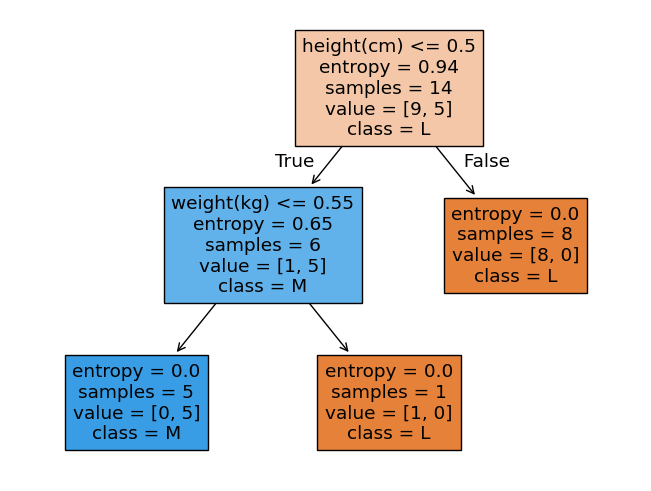

In [64]:
# Can a decision tree do better? 
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_clf = DecisionTreeClassifier(criterion="entropy")

# task: take it from here!

tree_clf.fit(X_train, y_train)
y_predicted = tree_clf.predict(X_test)
tree_acc = accuracy_score(y_test, y_predicted)
print(f"tree accuracy: {tree_acc}")
tree_cm = confusion_matrix(y_test, y_predicted)
print(tree_cm)



plt.figure(layout="constrained")
plot_tree(tree_clf, filled=True, feature_names=df.columns,class_names = sorted(y.unique()))
plt.show()

## k Fold Cross Validation
- With cross validation, every instance is in hte test set exactly one time
- Basic Alg: divide the dataset into folds
    - For each fold
        - Test on the fold
        - train on the remaining folds
- Accuracy is total correctly predicted over all the folds divided by the total number of instances
- This gives you a baseline idea of how well your model is likely to perform on unseen data.
- After using cross validation to evaluate and compare models, train your final model on the full dataset.

In [65]:
from sklearn.model_selection import cross_val_score, cross_val_predict
import numpy as np

# do 5 fold cross validation for both the knn and decision tree classifiers
tree_clf = DecisionTreeClassifier()
knn_clf_1 = KNeighborsClassifier(n_neighbors=1, metric="euclidean")
knn_clf_3 = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_clf_7 = KNeighborsClassifier(n_neighbors=7, metric="euclidean")

for clf in [knn_clf_1, knn_clf_3, knn_clf_7, tree_clf]:
    print(type(clf))
    # accuracies = cross_val_score(clf, X_scaled, y, cv=5)
    # print(accuracies, np.mean(accuracies))
    
    # better way to calculate accuracy
    y_predicted = cross_val_predict(clf, X_scaled, y, cv=5)
    acc = accuracy_score(y, y_predicted)
    print(acc)
    print(confusion_matrix(y, y_predicted))


<class 'sklearn.neighbors._classification.KNeighborsClassifier'>
0.7777777777777778
[[8 3]
 [1 6]]
<class 'sklearn.neighbors._classification.KNeighborsClassifier'>
0.7777777777777778
[[8 3]
 [1 6]]
<class 'sklearn.neighbors._classification.KNeighborsClassifier'>
0.8888888888888888
[[10  1]
 [ 1  6]]
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
0.9444444444444444
[[10  1]
 [ 0  7]]
